In [72]:
import pandas as pd

df=pd.read_csv("../data/immo_data.csv")
print(df.head())

                regio1  serviceCharge                     heatingType  \
0  Nordrhein_Westfalen         245.00                 central_heating   
1      Rheinland_Pfalz         134.00  self_contained_central_heating   
2              Sachsen         255.00                   floor_heating   
3              Sachsen          58.15                district_heating   
4               Bremen         138.00  self_contained_central_heating   

  telekomTvOffer  telekomHybridUploadSpeed  newlyConst  balcony  picturecount  \
0  ONE_YEAR_FREE                       NaN       False    False             6   
1  ONE_YEAR_FREE                       NaN       False     True             8   
2  ONE_YEAR_FREE                      10.0        True     True             8   
3  ONE_YEAR_FREE                       NaN       False     True             9   
4            NaN                       NaN       False     True            19   

   pricetrend  telekomUploadSpeed  ...               regio2  \
0        4.

In [73]:
print(df.shape)
print(list(df.columns))

(268850, 49)
['regio1', 'serviceCharge', 'heatingType', 'telekomTvOffer', 'telekomHybridUploadSpeed', 'newlyConst', 'balcony', 'picturecount', 'pricetrend', 'telekomUploadSpeed', 'totalRent', 'yearConstructed', 'scoutId', 'noParkSpaces', 'firingTypes', 'hasKitchen', 'geo_bln', 'cellar', 'yearConstructedRange', 'baseRent', 'houseNumber', 'livingSpace', 'geo_krs', 'condition', 'interiorQual', 'petsAllowed', 'street', 'streetPlain', 'lift', 'baseRentRange', 'typeOfFlat', 'geo_plz', 'noRooms', 'thermalChar', 'floor', 'numberOfFloors', 'noRoomsRange', 'garden', 'livingSpaceRange', 'regio2', 'regio3', 'description', 'facilities', 'heatingCosts', 'energyEfficiencyClass', 'lastRefurbish', 'electricityBasePrice', 'electricityKwhPrice', 'date']


In [74]:
nrw=df[df["regio1"]=="Nordrhein_Westfalen"]
print(nrw.shape)
print(nrw["regio2"].value_counts().head(20))

(62863, 49)
regio2
Essen                   4351
Düsseldorf              3711
Duisburg                3522
Dortmund                3137
Gelsenkirchen           2943
Recklinghausen_Kreis    2754
Köln                    2709
Wuppertal               2376
Bochum                  2007
Aachen                  1889
Märkischer_Kreis        1551
Mettmann_Kreis          1494
Hagen                   1437
Ennepe_Ruhr_Kreis       1398
Mönchengladbach         1369
Krefeld                 1342
Bonn                    1321
Rhein_Sieg_Kreis        1177
Neuss_Rhein_Kreis       1172
Wesel_Kreis             1167
Name: count, dtype: int64


In [75]:
cities_pattern="K.{1,2}ln|D.{1,2}sseldorf|Aachen|Bochum|Dortmund|Duisburg|Essen"
city_df=nrw[nrw["regio2"].str.contains(cities_pattern,case=False, na=False)].copy()
print(city_df.shape)
print(city_df["regio2"].value_counts())

(22282, 49)
regio2
Essen           4351
Düsseldorf      3711
Duisburg        3522
Dortmund        3137
Köln            2709
Bochum          2007
Aachen          1889
Aachen_Kreis     956
Name: count, dtype: int64


In [76]:
city_df=city_df[city_df["regio2"]!="Aachen_Kreis"].copy()
print(city_df.shape)
print(city_df["regio2"].value_counts())

(21326, 49)
regio2
Essen         4351
Düsseldorf    3711
Duisburg      3522
Dortmund      3137
Köln          2709
Bochum        2007
Aachen        1889
Name: count, dtype: int64


In [77]:
cols=["regio2","baseRent","livingSpace","date"]
print(city_df[cols].isna().sum())
print(city_df[cols].describe())

regio2         0
baseRent       0
livingSpace    0
date           0
dtype: int64
            baseRent   livingSpace
count   21326.000000  21326.000000
mean      687.128947     73.120404
std       955.876153    105.931152
min         9.500000      0.000000
25%       390.000000     53.450000
50%       520.000000     66.000000
75%       800.000000     83.600000
max    120000.000000  14000.000000


In [78]:
before=len(city_df)
clean_df=city_df[
    
    (city_df["baseRent"].between(100,4000)) &
    (city_df["livingSpace"].between(10, 250)) 

].copy()

print("Before:", before)
print("After:", len(clean_df))
print("Removed:", before-len(clean_df))
print(clean_df[["baseRent","livingSpace"]].describe())

Before: 21326
After: 21250
Removed: 76
           baseRent   livingSpace
count  21250.000000  21250.000000
mean     670.299799     71.668220
std      440.731185     29.667799
min      100.000000     10.000000
25%      390.000000     53.382500
50%      520.000000     66.000000
75%      798.000000     83.000000
max     4000.000000    250.000000


In [79]:
clean_df["price_per_sqm"]=clean_df["baseRent"]/clean_df["livingSpace"]
summary=clean_df.groupby("regio2")["price_per_sqm"].agg(["mean","median","count"])
summary=summary.sort_values("mean",ascending=False).round(2)
print(summary)

             mean  median  count
regio2                          
Köln        14.11   12.57   2700
Düsseldorf  12.67   11.97   3672
Aachen       9.82    9.42   1887
Dortmund     8.04    7.71   3129
Essen        7.64    7.22   4341
Bochum       7.45    7.14   2004
Duisburg     6.26    6.02   3517


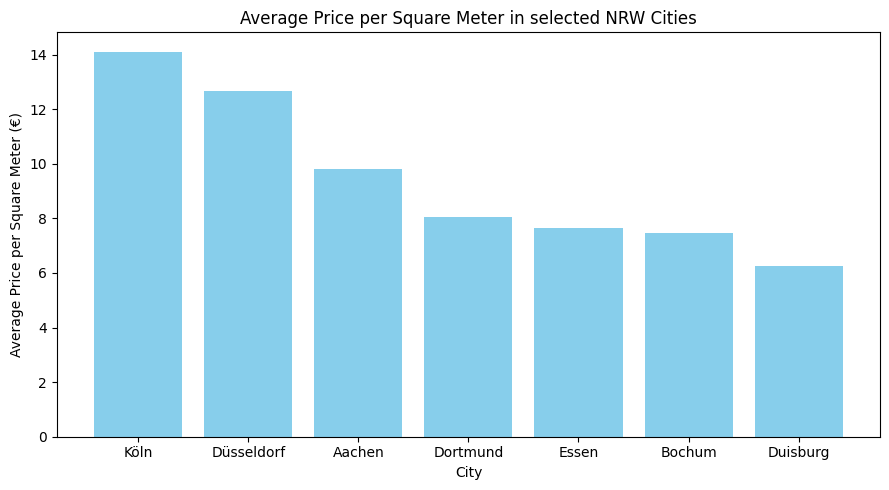

In [80]:
import matplotlib.pyplot as plt


plot_data=summary.reset_index()

plt.figure(figsize=(9,5))
plt.bar(plot_data["regio2"], plot_data["mean"], color="skyblue")
plt.title("Average Price per Square Meter in selected NRW Cities")
plt.xlabel("City")
plt.ylabel("Average Price per Square Meter (€)")
plt.tight_layout()
plt.show()